In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [2]:
%%R
library(DEGRE)
library(edgeR)
library(glmmTMB)
library(glmmSeq)
library(emmeans)
library(ggplot2)
library(pbmcapply)
library(BiocParallel)
library(MASS)

Loading required package: limma

Attaching package: ‘glmmSeq’

The following object is masked from ‘package:edgeR’:

    maPlot

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Loading required package: parallel
In addition: Warning message:
In check_dep_version(dep_pkg = "TMB") : package version mismatch: 
glmmTMB was built with TMB package version 1.9.15
Current TMB package version is 1.9.16
Please re-install glmmTMB from source or restore original ‘TMB’ package (see '?reinstalling' for more information)


In [3]:
%%R
set.seed(1234)

# Remove libraries that are too small

In [4]:
adata_pb = sc.read('./pb_adata_MG_noPVM.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 105 × 29040
    obs: 'sample', 'sample_lesion', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [5]:
adata_pb.obs['cell_stim'] = adata_pb.obs['cell_type'].astype(str) + '_' + adata_pb.obs['stim'].astype(str)

In [6]:
# Extract the log_lib_size column
log_lib_size = adata_pb.obs['log_lib_size']

# Compute the median
median = np.median(log_lib_size)

# Compute the MAD (Median Absolute Deviation)
mad = np.median(np.abs(log_lib_size - median))

# Define the upper and lower thresholds
upper_threshold = median + 3 * mad
lower_threshold = median - 3 * mad

# Find outliers
outliers = adata_pb.obs[(log_lib_size < lower_threshold)]

# Print the results
print(f"Median: {median}, MAD: {mad}")
print(f"Lower threshold: {lower_threshold}")
print(f"Outliers:\n{outliers}")

Median: 13.41974723497286, MAD: 1.0114790918083205
Lower threshold: 10.385309959547898
Outliers:
                                  sample      sample_lesion diagnosis  \
donor_Ind147-Sample1_0-0  Ind147-Sample1  Ind147-Sample1_RL      SPMS   
donor_Ind115-Sample2_0-1  Ind115-Sample2  Ind115-Sample2_AL      SPMS   

                         sample_source cell_type sample_rep replicate_cat  \
donor_Ind147-Sample1_0-0  Amsterdam BB        Mg      RL_11            11   
donor_Ind115-Sample2_0-1  Amsterdam BB       PVM      AL_21            21   

                         stim sex seq_pool age_scale    age_cat    pmi_cat  \
donor_Ind147-Sample1_0-0   RL   F   Pool 1  0.370209  inbetween  6H_to_12H   
donor_Ind115-Sample2_0-1   AL   M   Pool 1 -0.866516   under_50  6H_to_12H   

                           pmi_cat2 batch  lib_size  log_lib_size cell_stim  
donor_Ind147-Sample1_0-0  up_to_12H     0     13863      9.536979     Mg_RL  
donor_Ind115-Sample2_0-1  up_to_12H     1     17890      9.7

In [8]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 105


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
Mg,21,17,13,15,11,12
PVM,5,3,2,2,4,0


In [9]:
# Define the list of samples to remove
samples_to_remove = ["donor_Ind147-Sample1_0-0", "donor_Ind115-Sample2_0-1"
]

# Filter out the samples to remove
adata_pb = adata_pb[~adata_pb.obs.index.isin(samples_to_remove)].copy()

# Confirm removal
print(f"Remaining samples: {adata_pb.shape[0]}")

Remaining samples: 103


In [10]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 103


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
Mg,21,17,13,15,10,12
PVM,4,3,2,2,4,0


## Subset to cell type to test

In [11]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['Mg'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (88, 29040)


In [12]:
adata_sub= adata_sub[np.in1d(adata_sub.obs['stim'], 
                           ['WM',
                              'AL'
                           ])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (33, 29040)


In [13]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [14]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [15]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,cell_stim,sample_lesion
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,Mg,WM_1,1,WM,M,Pool_6,-1.759706,under_50,over_12H,over_12H,0,394287,12.884834,Mg_WM,Ind98-Sample2_WM
Ind102-Sample1_AL,Ind102-Sample1,SPMS,Amsterdam BB,Mg,AL_1,1,AL,M,Pool_4,0.301502,inbetween,6H_to_12H,up_to_12H,0,491082,13.104366,Mg_AL,Ind102-Sample1_AL
Ind103-Sample1_AL,Ind103-Sample1,RRMS,Amsterdam BB,Mg,AL_2,2,AL,F,Pool_3,-1.484878,under_50,up_to_6H,up_to_12H,0,289637,12.576384,Mg_AL,Ind103-Sample1_AL
Ind106-Sample1_AL,Ind106-Sample1,SPMS,UK MS TB,Mg,AL_3,3,AL,M,Pool_2,0.164088,inbetween,over_12H,over_12H,0,347805,12.759397,Mg_AL,Ind106-Sample1_AL
Ind107-Sample1_WM,Ind107-Sample1,CTR,Edinburgh BB,Mg,WM_3,3,WM,M,Pool_3,-0.935223,under_50,over_12H,over_12H,0,811347,13.606451,Mg_WM,Ind107-Sample1_WM


In [16]:
for col in adata_sub.obs.columns:
    if pd.api.types.is_categorical_dtype(adata_sub.obs[col]):
        adata_sub.obs[col] = adata_sub.obs[col].astype(str)

In [17]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,cell_stim,sample_lesion,indiv_id
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,Mg,WM_1,1,WM,M,Pool_6,-1.75970576219065,under_50,over_12H,over_12H,0,394287,12.884834,Mg_WM,Ind98-Sample2_WM,Ind98
Ind102-Sample1_AL,Ind102-Sample1,SPMS,Amsterdam BB,Mg,AL_1,1,AL,M,Pool_4,0.301502181578831,inbetween,6H_to_12H,up_to_12H,0,491082,13.104366,Mg_AL,Ind102-Sample1_AL,Ind102
Ind103-Sample1_AL,Ind103-Sample1,RRMS,Amsterdam BB,Mg,AL_2,2,AL,F,Pool_3,-1.48487803635472,under_50,up_to_6H,up_to_12H,0,289637,12.576384,Mg_AL,Ind103-Sample1_AL,Ind103
Ind106-Sample1_AL,Ind106-Sample1,SPMS,UK MS TB,Mg,AL_3,3,AL,M,Pool_2,0.164088318660865,inbetween,over_12H,over_12H,0,347805,12.759397,Mg_AL,Ind106-Sample1_AL,Ind106
Ind107-Sample1_WM,Ind107-Sample1,CTR,Edinburgh BB,Mg,WM_3,3,WM,M,Pool_3,-0.93522258468286,under_50,over_12H,over_12H,0,811347,13.606451,Mg_WM,Ind107-Sample1_WM,Ind107


In [18]:
# Subset to WM samples
wm_df = adata_sub.obs[adata_sub.obs["stim"] == "WM"]

# Find index (sample) with max lib_size
max_lib_sample = wm_df["lib_size"].idxmax()

print("WM sample with largest library size:", max_lib_sample)

WM sample with largest library size: Ind145-Sample1_WM


In [19]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_stim', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)
summary_table

stim,AL,WM
cell_stim,,
Mg_AL,21,0
Mg_WM,0,12


In [20]:
#Check the counts data
print(adata_sub.X[:5, :5])

[[ 5  1  0  0 13]
 [ 0  0  0  0 35]
 [ 4  0  0  0 12]
 [12  0  0  0  6]
 [14  0  1  0 40]]


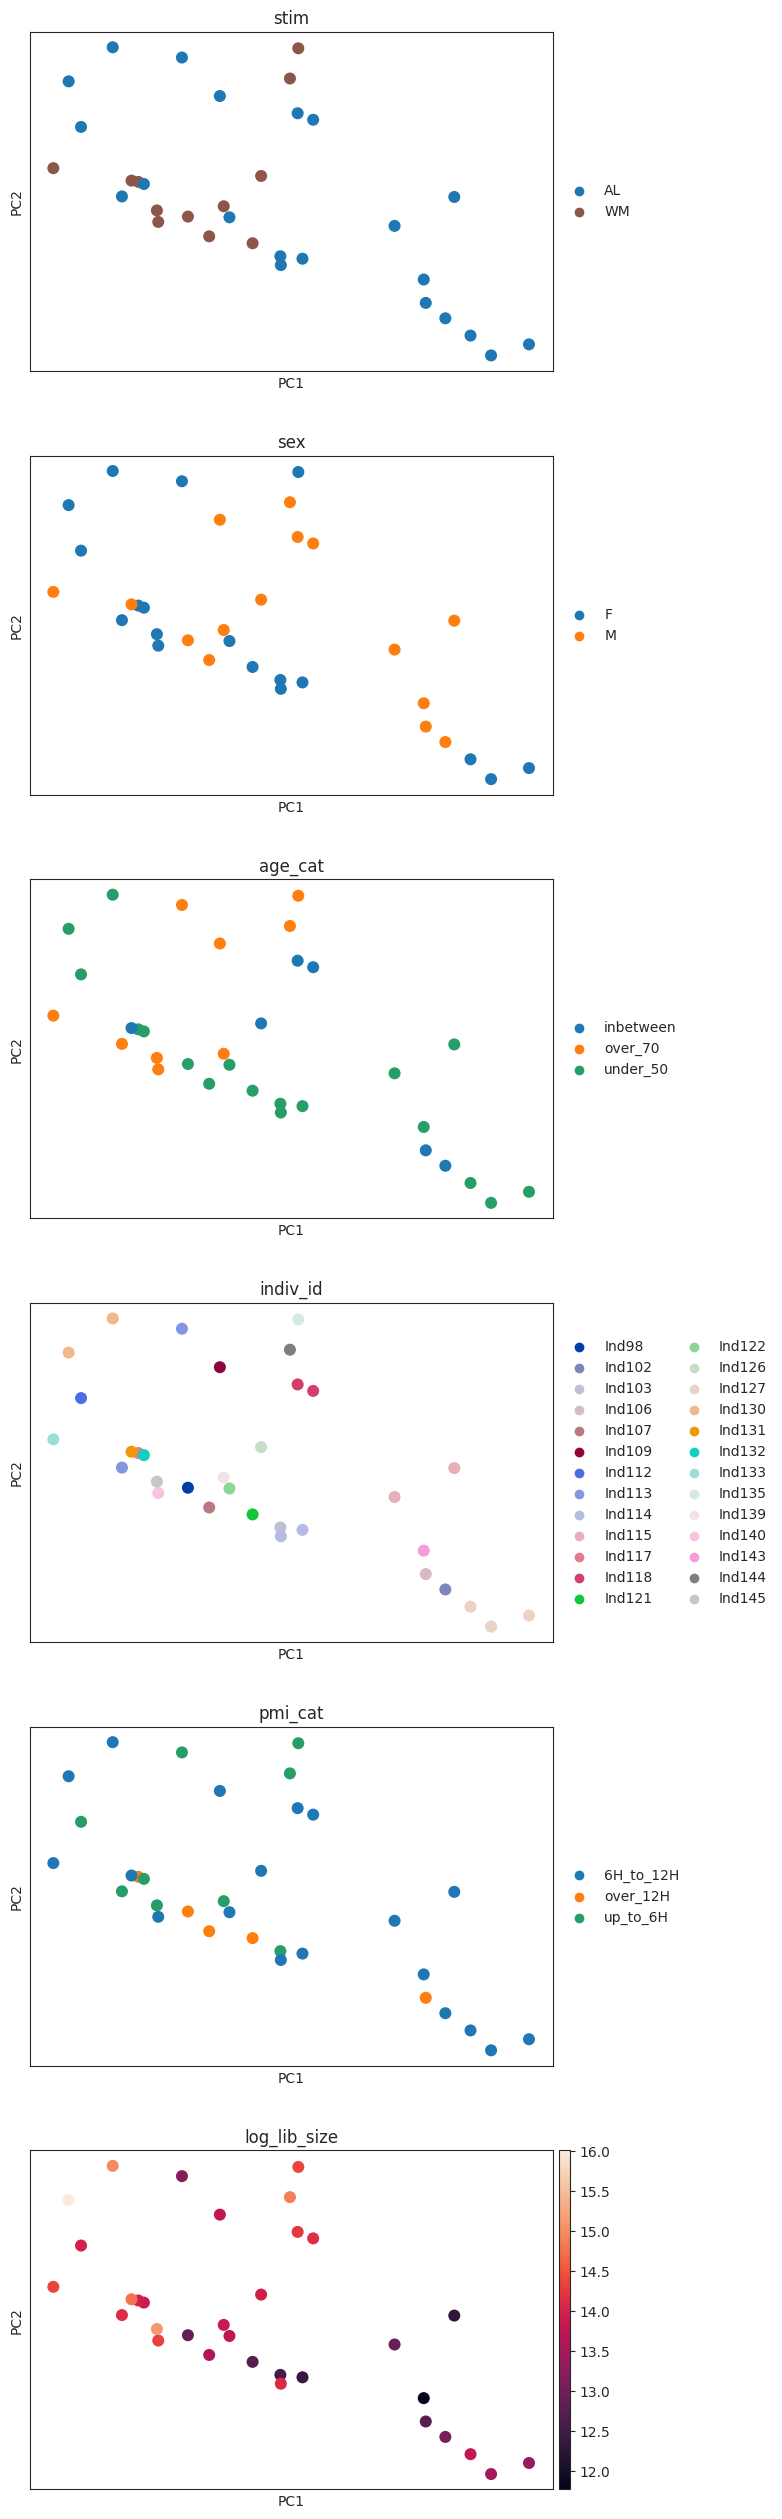

In [21]:
sc.pl.pca(adata_sub, color=["stim", "sex", "age_cat", "indiv_id",
                            "pmi_cat", "log_lib_size"], 
          ncols=1, size=300)

## Set up data

In [22]:
%%R -i adata_sub

# Create the treatments dataframe with samples as a column, not as row names
treatments <- data.frame(
  #Sample = colData(adata_sub)$sample,      # Sample column
  Group = colData(adata_sub)$stim,        # Group (e.g., ctrl or stim)
  Donor = colData(adata_sub)$indiv_id,    # Donor information
  Sex = colData(adata_sub)$sex,           # Sex information
  Age_cat = colData(adata_sub)$age_cat,   # Age category
  Pmi_cat = colData(adata_sub)$pmi_cat   # Post-mortem interval category
)

treatments$Group   <- factor(treatments$Group)
treatments$Donor   <- factor(treatments$Donor)
treatments$Sex     <- factor(treatments$Sex)
treatments$Age_cat <- factor(treatments$Age_cat)
treatments$Pmi_cat <- factor(treatments$Pmi_cat)

# Check the updated dataframe to confirm
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H
Ind109-Sample1_AL    AL Ind109   M   over_70 6H_to_12H


In [23]:
%%R

#Create a DGElist object using the anndata counts in 'X'
x <- DGEList(assay(adata_sub, "X"), group=colData(adata_sub)$stim)

samplenames <- colnames(x$counts)

print("Dimensions before subsetting:")
print(dim(x))

# Check counts per group before filtering
print(table(x$samples$group))

[1] "Dimensions before subsetting:"
[1] 29040    33

AL WM 
21 12 


In [24]:
%%R

# Adjust for batch-- ie publication in the model matrix
design_full <- model.matrix(~0 + Group + Sex + Age_cat + Pmi_cat, data=treatments)

rownames(design_full) <- colnames(x)
colnames(design_full)

[1] "GroupAL"         "GroupWM"         "SexM"            "Age_catover_70" 
[5] "Age_catunder_50" "Pmi_catover_12H" "Pmi_catup_to_6H"


In [25]:
%%R

# More strict removal of genes, tried group, pub and batch
keep.expr <- filterByExpr(x, design_full)
x2 <- x[keep.expr,, keep.lib.sizes=FALSE]
dim(x2)

[1] 12588    33


In [26]:
%%R

## Calc norm factors before to normalize library sizes, then cpm divides counts by lib sizes
#X is before trimming, Y is after trimming, X2 is also trimmed but differently
x2 <- calcNormFactors(x2, method = "TMM")
x2$samples$norm.factors

 [1] 1.0766186 0.9455789 1.0797250 0.9872377 1.0132380 0.9672444 1.1490255
 [8] 1.1447981 1.1187137 0.9576552 1.1366753 1.0019419 0.9642654 1.0754421
[15] 0.9118819 0.8984646 1.0947931 1.1335517 0.8890273 0.8633110 0.8112295
[22] 0.7958930 1.0297230 1.0634205 1.0050352 1.1170272 1.0956584 0.7751187
[29] 1.0133636 1.0716807 1.1265673 0.8559634 1.0255524


In [27]:
%%R 

# Extract the counts matrix from the DGEList object
counts_matrix <- x2$counts
counts_matrix <- as.data.frame(counts_matrix)

# Verify the structure and dimensions of the extracted matrix
print(dim(counts_matrix))  # Check dimensions

[1] 12588    33


In [28]:
%%R
all(rownames(treatments) == colnames(counts_matrix))  # Should return TRUE

[1] TRUE


## Add pseudocount of 1 to any gene with all 0 in either condition

In [29]:
%%R

wm_samples <- colnames(counts_matrix)[grepl("_WM$", colnames(counts_matrix))]
cat("Number of WM samples:", length(wm_samples), "\n")


all_zero_wm <- character()
for (gene in rownames(counts_matrix)) {
  wm_counts <- counts_matrix[gene, wm_samples]
  
  if (all(wm_counts == 0)) {
    all_zero_wm <- c(all_zero_wm, gene)
  }
}

# Report
cat("Genes with ALL WM counts = 0:\n")
print(all_zero_wm)

Number of WM samples: 12 
Genes with ALL WM counts = 0:
[1] "AC007563.2" "IGHG4"      "IGHGP"      "IGHG1"      "IGHG3"     
[6] "RTN4R"     


In [30]:
%%R

al_samples <- colnames(counts_matrix)[grepl("_AL$", colnames(counts_matrix))]
cat("Number of AL samples:", length(al_samples), "\n")

all_zero_al <- character()
for (gene in rownames(counts_matrix)) {
  al_counts <- counts_matrix[gene, al_samples]
  
  if (all(al_counts == 0)) {
    all_zero_al <- c(all_zero_al, gene)
  }
}

# Report
cat("Genes with ALL AL counts = 0:\n")
print(all_zero_al)

Number of AL samples: 21 
Genes with ALL AL counts = 0:
character(0)


In [31]:
# Subset to WM samples
wm_df = adata_sub.obs[adata_sub.obs["stim"] == "WM"]

# Find index (sample) with max lib_size
max_lib_sample = wm_df["lib_size"].idxmax()

print("WM sample with largest library size:", max_lib_sample)

WM sample with largest library size: Ind145-Sample1_WM


In [32]:
%%R

# Report
cat("Genes with ALL WM counts = 0:\n")
cat(paste0('"', all_zero_wm, '"', collapse = ", "), "\n")

Genes with ALL WM counts = 0:
"AC007563.2", "IGHG4", "IGHGP", "IGHG1", "IGHG3", "RTN4R" 


In [33]:
%%R

genes_to_update <- c("AC007563.2", "IGHG4", "IGHGP", "IGHG1", "IGHG3", "RTN4R" )
sample_col <- "Ind145-Sample1_WM"

counts_matrix[genes_to_update, sample_col] <- counts_matrix[genes_to_update, sample_col] + 1

## Add TMM norm log lib size offset

In [ ]:
%%R

#counts_matrix <- readRDS("./files/counts_matrix_WMvAL_OPCs.rds")
#treatments <- readRDS("./files/treatments_WMvAL_OPCs.rds")

In [34]:
%%R
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H
Ind109-Sample1_AL    AL Ind109   M   over_70 6H_to_12H


In [35]:
%%R

#log_lib_size <- log(colSums(counts_matrix))
effective_lib_size <- x2$samples$lib.size * x2$samples$norm.factors
log_lib_size <- log(effective_lib_size)

In [36]:
%%R
all(names(log_lib_size) == rownames(treatments))

[1] TRUE


In [37]:
%%R
treatments$log_lib_size <- log_lib_size
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat log_lib_size
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H     12.94897
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H     13.03849
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H     12.64413
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H     12.73614
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H     13.61131
Ind109-Sample1_AL    AL Ind109   M   over_70 6H_to_12H     13.74123


## Test glmmTMB

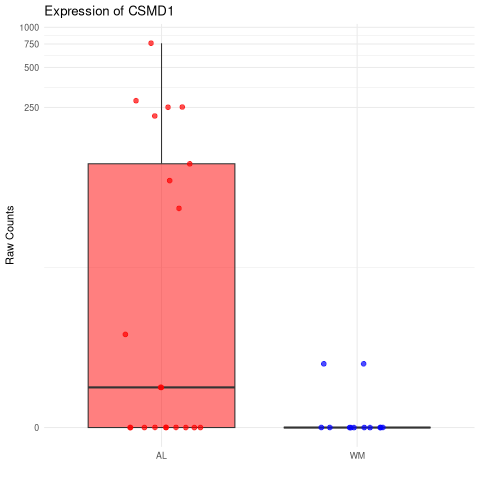

In [38]:
%%R

# Specify your gene
gene_to_plot <- "CSMD1"

# Create a data frame with counts and metadata
gene_data <- data.frame(
  expression = as.numeric(counts_matrix[gene_to_plot, ]),
  Group = treatments$Group
)

# Label treatment as WM vs AL (if not already factors)
gene_data$treatment <- factor(gene_data$Group, levels = c("AL", "WM"))

# Inspect
head(gene_data)

# Make the plot
ggplot(gene_data, aes(x = treatment, y = expression, fill = treatment)) +
  geom_boxplot(alpha = 0.5, outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 2, aes(color = treatment)) +
  scale_fill_manual(values = c("WM" = "blue", "AL" = "red")) +
  scale_color_manual(values = c("WM" = "blue", "AL" = "red")) +
  labs(
    title = paste("Expression of", gene_to_plot),
    x = "",
    y = "Raw Counts"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_y_continuous(trans = "log1p")  # log scale for counts

In [39]:
%%R
# Compute CPM matrix
cpm_matrix <- edgeR::cpm(as.matrix(counts_matrix))

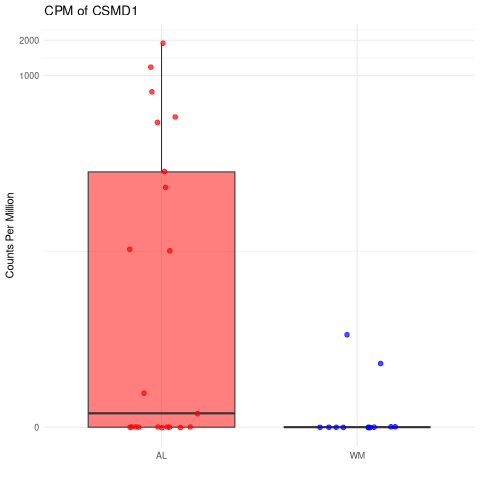

In [40]:
%%R

# Specify your gene
gene_to_plot <- "CSMD1"

# Create a data frame with counts and metadata
gene_data <- data.frame(
  cpm = as.numeric(cpm_matrix[gene_to_plot, ]),
  Group = treatments$Group
)

# Label treatment as WM vs AL (if not already factors)
gene_data$treatment <- factor(gene_data$Group, levels = c("AL", "WM"))

# Inspect
head(gene_data)

ggplot(gene_data, aes(x = treatment, y = cpm, fill = treatment)) +
  geom_boxplot(alpha = 0.5, outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 2, aes(color = treatment)) +
  scale_fill_manual(values = c("WM" = "blue", "AL" = "red")) +
  scale_color_manual(values = c("WM" = "blue", "AL" = "red")) +
  labs(
    title = paste("CPM of", gene_to_plot),
    x = "",
    y = "Counts Per Million"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_y_continuous(trans = "log1p")  # log scale

In [41]:
%%R

# Replace with your gene name
gene_to_test <- "CSMD1"  

# Add gene counts to treatments
treatments$counts <- as.numeric(counts_matrix[gene_to_test, ])

# Fit the model
fit <- tryCatch({
  glmmTMB(
    counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
    data = treatments,
    family = nbinom2()
  )
}, error = function(e) {
  message("Model failed: ", e$message)
  NULL
})

if (!is.null(fit)) {
  # Extract coefficients
  coef_table <- summary(fit)$coefficients$cond
  
  if ("GroupWM" %in% rownames(coef_table)) {
    logFC   <- coef_table["GroupWM", "Estimate"]
    std_err <- coef_table["GroupWM", "Std. Error"]
    pval    <- coef_table["GroupWM", "Pr(>|z|)"]
    
    cat("Results for gene:", gene_to_test, "\n")
    cat("logFC_WM:", logFC, "\n")
    cat("SE:", std_err, "\n")
    cat("p-value:", pval, "\n")
  } else {
    cat("No GroupWM coefficient found.\n")
  }
} else {
  cat("Model fitting failed.\n")
}

Results for gene: CSMD1 
logFC_WM: -7.681286 
SE: 2.636641 
p-value: 0.003576486 


In [42]:
%%R
diagnose(fit)

Unusually large coefficients (|x|>10):

Age_catover_70 
     -30.28442 

Large negative coefficients in zi (log-odds of zero-inflation),
dispersion, or random effects (log-standard deviations) suggest
unnecessary components (converging to zero on the constrained scale);
large negative and/or positive components in binomial or Poisson
conditional parameters suggest (quasi-)complete separation. Large
values of nbinom2 dispersion suggest that you should use a Poisson
model instead.




In [43]:
%%R
fit_full <- glmmTMB(counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
                    data = treatments, family = nbinom2(), offset = log_lib_size)

fit_noRE <- glmmTMB(counts ~ Group + Sex + Age_cat + Pmi_cat,
                    data = treatments, family = nbinom2(), offset = log_lib_size)

anova(fit_noRE, fit_full)

Data: treatments
Models:
fit_noRE: counts ~ Group + Sex + Age_cat + Pmi_cat, zi=~0, disp=~1
fit_full: counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor), zi=~0, disp=~1
         Df   AIC    BIC  logLik deviance Chisq Chi Df Pr(>Chisq)
fit_noRE  8 181.5 193.47 -82.749    165.5                        
fit_full  9 183.5 196.97 -82.749    165.5     0      1          1


In [44]:
%%R
diagnose(fit_full)

Unusually large coefficients (|x|>10):

   (Intercept) Age_catover_70 
     -12.18816      -23.59340 

Large negative coefficients in zi (log-odds of zero-inflation),
dispersion, or random effects (log-standard deviations) suggest
unnecessary components (converging to zero on the constrained scale);
large negative and/or positive components in binomial or Poisson
conditional parameters suggest (quasi-)complete separation. Large
values of nbinom2 dispersion suggest that you should use a Poisson
model instead.


Unusually large Z-statistics (|x|>5):

     (Intercept) disp~(Intercept) 
       -6.404066        -5.310337 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While

In [45]:
%%R
diagnose(fit_noRE)

Unusually large coefficients (|x|>10):

   (Intercept) Age_catover_70 
     -12.18814      -23.08247 

Large negative coefficients in zi (log-odds of zero-inflation),
dispersion, or random effects (log-standard deviations) suggest
unnecessary components (converging to zero on the constrained scale);
large negative and/or positive components in binomial or Poisson
conditional parameters suggest (quasi-)complete separation. Large
values of nbinom2 dispersion suggest that you should use a Poisson
model instead.


Unusually large Z-statistics (|x|>5):

     (Intercept) disp~(Intercept) 
       -6.404075        -5.310339 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While

In [46]:
%%R

# Replace with your gene name
gene_to_test <- "HGF"  

# Add gene counts to treatments
treatments$counts <- as.numeric(counts_matrix[gene_to_test, ])

# Fit the model
fit <- tryCatch({
  glmmTMB(
    counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
    data = treatments,
    family = nbinom2(),
    offset = log_lib_size
  )
}, error = function(e) {
  message("Model failed: ", e$message)
  NULL
})

if (!is.null(fit)) {
  # Extract coefficients
  coef_table <- summary(fit)$coefficients$cond
  
  if ("GroupWM" %in% rownames(coef_table)) {
    logFC   <- coef_table["GroupWM", "Estimate"]
    std_err <- coef_table["GroupWM", "Std. Error"]
    pval    <- coef_table["GroupWM", "Pr(>|z|)"]
    
    cat("Results for gene:", gene_to_test, "\n")
    cat("logFC_WM:", logFC, "\n")
    cat("SE:", std_err, "\n")
    cat("p-value:", pval, "\n")
  } else {
    cat("No GroupWM coefficient found.\n")
  }
} else {
  cat("Model fitting failed.\n")
}

Results for gene: HGF 
logFC_WM: -0.6713795 
SE: 0.2328818 
p-value: 0.003940081 


In [47]:
%%R
diagnose(fit)

Unusually large Z-statistics (|x|>5):

(Intercept) 
  -31.58194 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While the Wald p-values and standard errors
listed in summary() may be unreliable, profile confidence intervals
(see ?confint.glmmTMB) and likelihood ratio test p-values derived by
comparing models (e.g. ?drop1) are probably still OK.  (Note that the
LRT is conservative when the null value is on the boundary, e.g. a
variance or zero-inflation value of 0 (Self and Liang 1987; Stram and
Lee 1994; Goldman and Whelan 2000); in simple cases these p-values are
approximately twice as large as they should be.)




## Simpler models to consider?

In [ ]:
%%R
# Model with only Group
m1 <- glm.nb(counts ~ Group + offset(log_lib_size), data = treatments)

# Add Sex
m2 <- glm.nb(counts ~ Group + Sex + offset(log_lib_size), data = treatments)

# Add Age_cat
m3 <- glm.nb(counts ~ Group + Sex + Age_cat + offset(log_lib_size), data = treatments)

# Add Pmi_cat
m4 <- glm.nb(counts ~ Group + Sex + Age_cat + Pmi_cat + offset(log_lib_size), data = treatments)

# Compare AIC and convergence
AIC(m1, m2, m3, m4)

In [ ]:
%%R
# List of models
models <- list(m1, m2, m3, m4)
model_names <- c("Group", "Group + Sex", "Group + Sex + Age_cat", "Group + Sex + Age_cat + Pmi_cat")

# Set up 2x2 plotting grid
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

for (i in seq_along(models)) {
  fitted_vals <- fitted(models[[i]])
  
  plot(
    fitted_vals,
    treatments$counts,
    main = paste("Observed vs Fitted\n", model_names[i]),
    xlab = "Fitted counts",
    ylab = "Observed counts",
    pch = 19,
    col = "blue"
  )
  
  abline(0, 1, col = "red", lwd = 2)  # Reference line y = x
}

# Reset plotting layout
par(mfrow = c(1,1))

## Run full code...

In [48]:
%%R
Sys.getenv("NSLOTS")

[1] "24"


In [49]:
%%R

# Start time
start_time <- Sys.time()
formatted_start <- format(start_time, "%A, %B %d, %Y at %I:%M:%S %p")
cat("Started GLMM fitting at:", formatted_start, "\n")

# Number of cores
n_cores <- 24

# Genes to test
genes_to_test <- rownames(counts_matrix)
total_genes <- length(genes_to_test)

# Fit function
fit_gene <- function(gene) {
  if (!(gene %in% rownames(counts_matrix))) return(NULL)

  # Counts for this gene
  treatments$counts <- as.numeric(counts_matrix[gene, ])

  fit <- tryCatch({
    glmmTMB(
      counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
      data = treatments,
      family = nbinom2(),
      offset = log_lib_size
    )
  }, error = function(e) return(list(error = e$message)))

  # Handle errors
  if (is.list(fit) && "error" %in% names(fit)) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = NA,
      pdHess = NA,
      logLik = NA,
      AIC = NA,
      error = fit$error,
      stringsAsFactors = FALSE
    ))
  }

  # Get coefficient table
  coef_table <- summary(fit)$coefficients$cond

  # If GroupWM not found
  if (!("GroupWM" %in% rownames(coef_table))) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = fit$fit$convergence,
      pdHess = fit$sdr$pdHess,
      logLik = as.numeric(logLik(fit)),
      AIC = AIC(fit),
      error = "No GroupWM term",
      stringsAsFactors = FALSE
    ))
  }

  # Otherwise, record the metrics
  return(data.frame(
    gene = gene,
    logFC_WM = coef_table["GroupWM", "Estimate"],
    se = coef_table["GroupWM", "Std. Error"],
    pvalue = coef_table["GroupWM", "Pr(>|z|)"],
    convergence = fit$fit$convergence,
    pdHess = fit$sdr$pdHess,
    logLik = as.numeric(logLik(fit)),
    AIC = AIC(fit),
    error = NA,
    stringsAsFactors = FALSE
  ))
}

# Run in parallel
results_list <- pbmclapply(
  genes_to_test,
  fit_gene,
  mc.cores = n_cores
)

# Combine results
results_df <- do.call(rbind, Filter(Negate(is.null), results_list))

# Adjust p-values
results_df$FDR <- p.adjust(results_df$pvalue, method = "BH")
results_df <- results_df[order(results_df$FDR), ]

# Save to CSV for inspection
write.csv(results_df, "./files/GLMM_full_results_with_quality_ALvWM_MG_noPVM.csv", row.names = FALSE)

# Timing
end_time <- Sys.time()
formatted_end <- format(end_time, "%A, %B %d, %Y at %I:%M:%S %p")
cat("Finished at:", formatted_end, "\n")

# Compute runtime in minutes (use POSIXt objects!)
runtime_minutes <- difftime(end_time, start_time, units = "mins")
cat("Runtime:", runtime_minutes, "\n")

Started GLMM fitting at: Monday, October 20, 2025 at 09:38:51 AM 
  |=======================================================| 100%, Elapsed 08:13
Finished at: Monday, October 20, 2025 at 09:47:06 AM 
Runtime: 8.236533 


In [50]:
%%R
dim(results_df)

[1] 12588    10


In [51]:
%%R
head(results_df)

            gene   logFC_WM        se       pvalue convergence pdHess    logLik
3852  AC008691.1  3.0656211 0.4145585 1.415082e-13           0   TRUE -210.4721
10278    SLC46A1 -0.9044412 0.1272215 1.167306e-12           0  FALSE        NA
6409       STRBP  0.7053662 0.1109145 2.023457e-10           0   TRUE -180.8171
11701      TSHZ3 -2.6148332 0.4132612 2.494663e-10           0   TRUE -110.8953
8606       ABCC4  1.2055680 0.1925708 3.840221e-10           0   TRUE -223.6390
11172       MAFB -1.7986934 0.2900850 5.625767e-10           0   TRUE -169.0943
           AIC error          FDR
3852  438.9442    NA 1.773380e-09
10278       NA    NA 7.314340e-09
6409  379.6342    NA 7.815780e-07
11701 239.7906    NA 7.815780e-07
8606  465.2780    NA 9.625129e-07
11172 356.1885    NA 1.175035e-06


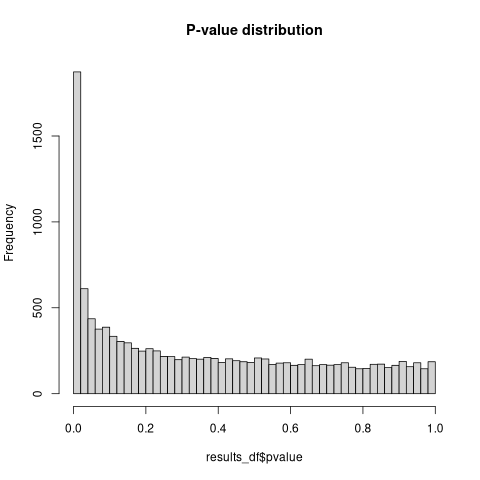

In [52]:
%%R
hist(results_df$pvalue, breaks = 50, main = "P-value distribution")

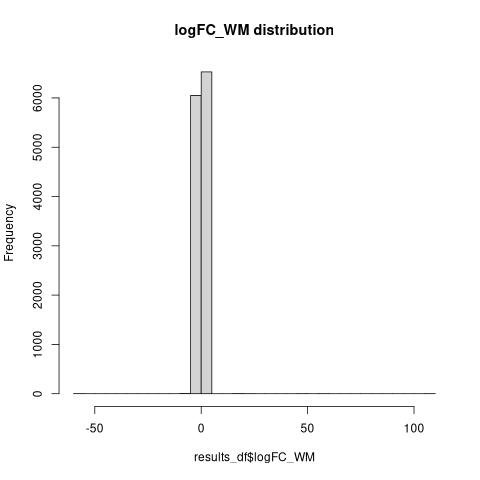

In [53]:
%%R
hist(results_df$logFC_WM, breaks = 50, main = "logFC_WM distribution")

In [54]:
%%R
table(results_df$convergence, results_df$pdHess)

   
    FALSE  TRUE
  0   243 10675
  1   470  1200


In [55]:
%%R

# Create a status flag column
results_df$status <- with(results_df, ifelse(
  convergence == 0 & pdHess == TRUE,
  "OK",
  "Check"
))

# Subset to keep only safe results
results_df_clean <- subset(results_df, status == "OK")

# Inspect how many genes remain
cat("Number of safe models:", nrow(results_df_clean), "\n")

# Write to CSV
write.csv(results_df_clean, "./files/GLMM_full_results_with_quality_ALvWM_MG_noPVM_cleaned.csv", row.names = FALSE)

Number of safe models: 10675 


In [56]:
%%R
head(results_df_clean)

            gene   logFC_WM        se       pvalue convergence pdHess    logLik
3852  AC008691.1  3.0656211 0.4145585 1.415082e-13           0   TRUE -210.4721
6409       STRBP  0.7053662 0.1109145 2.023457e-10           0   TRUE -180.8171
11701      TSHZ3 -2.6148332 0.4132612 2.494663e-10           0   TRUE -110.8953
8606       ABCC4  1.2055680 0.1925708 3.840221e-10           0   TRUE -223.6390
11172       MAFB -1.7986934 0.2900850 5.625767e-10           0   TRUE -169.0943
1232        AKT3  0.6798846 0.1112351 9.830495e-10           0   TRUE -213.8245
           AIC error          FDR status
3852  438.9442    NA 1.773380e-09     OK
6409  379.6342    NA 7.815780e-07     OK
11701 239.7906    NA 7.815780e-07     OK
8606  465.2780    NA 9.625129e-07     OK
11172 356.1885    NA 1.175035e-06     OK
1232  445.6490    NA 1.701168e-06     OK


In [57]:
%%R
# Subset for significant and strong effect size
sig_results <- subset(
  results_df_clean,
  FDR < 0.05 & abs(logFC_WM) >= 0.585
)

# See how many
cat("Number of significant genes:", nrow(sig_results), "\n")

# View top rows
head(sig_results)

Number of significant genes: 563 
            gene   logFC_WM        se       pvalue convergence pdHess    logLik
3852  AC008691.1  3.0656211 0.4145585 1.415082e-13           0   TRUE -210.4721
6409       STRBP  0.7053662 0.1109145 2.023457e-10           0   TRUE -180.8171
11701      TSHZ3 -2.6148332 0.4132612 2.494663e-10           0   TRUE -110.8953
8606       ABCC4  1.2055680 0.1925708 3.840221e-10           0   TRUE -223.6390
11172       MAFB -1.7986934 0.2900850 5.625767e-10           0   TRUE -169.0943
1232        AKT3  0.6798846 0.1112351 9.830495e-10           0   TRUE -213.8245
           AIC error          FDR status
3852  438.9442    NA 1.773380e-09     OK
6409  379.6342    NA 7.815780e-07     OK
11701 239.7906    NA 7.815780e-07     OK
8606  465.2780    NA 9.625129e-07     OK
11172 356.1885    NA 1.175035e-06     OK
1232  445.6490    NA 1.701168e-06     OK


In [58]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM >= 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_WM, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 262
            gene logFC_WM        se       pvalue convergence pdHess     logLik
12448 AJ009632.2 4.531003 1.5583285 0.0036420875           0   TRUE  -76.15001
1046      PPFIA4 3.764061 1.2014914 0.0017313323           0   TRUE  -64.77943
7573     CYP26C1 3.673351 1.0471761 0.0004517204           0   TRUE  -60.79922
11219 AL139351.2 3.599557 1.0512219 0.0006166928           0   TRUE  -84.39642
4109       HCG22 3.354083 1.1617307 0.0038875738           0   TRUE -121.04982
5181   LINC00996 3.093085 0.7578426 0.0000447585           0   TRUE  -83.33799
           AIC error         FDR status
12448 170.3000    NA 0.047643675     OK
1046  147.5589    NA 0.030093005     OK
7573  139.5984    NA 0.012721259     OK
11219 186.7928    NA 0.015804488     OK
4109  260.0996    NA 0.049423244     OK
5181  184.6760    NA 0.002638414     OK


In [59]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM <= -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_WM, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 316
        gene  logFC_WM       se       pvalue convergence pdHess     logLik
5627   CSMD1 -8.648314 2.754630 1.692045e-03           0   TRUE  -82.74872
3861  GABRB2 -5.102557 1.554200 1.026809e-03           0   TRUE  -85.64519
2711   SHOX2 -4.884892 1.406873 5.162817e-04           0   TRUE  -81.23868
10453   GFAP -4.336779 1.103333 8.472779e-05           0   TRUE -109.05206
7826   CD163 -4.332944 0.891304 1.165858e-06           0   TRUE -149.44717
8167   TRHDE -4.323725 1.086534 6.909702e-05           0   TRUE -121.03922
           AIC error          FDR status
5627  183.4974    NA 0.0298657787     OK
3861  189.2904    NA 0.0224180574     OK
2711  180.4774    NA 0.0138248757     OK
10453 236.1041    NA 0.0041803489     OK
7826  316.8943    NA 0.0002057821     OK
8167  260.0784    NA 0.0036231123     OK


In [60]:
%%R
genes_up_sorted

            gene  logFC_WM        se       pvalue convergence pdHess     logLik
12448 AJ009632.2 4.5310027 1.5583285 3.642088e-03           0   TRUE  -76.15001
1046      PPFIA4 3.7640610 1.2014914 1.731332e-03           0   TRUE  -64.77943
7573     CYP26C1 3.6733510 1.0471761 4.517204e-04           0   TRUE  -60.79922
11219 AL139351.2 3.5995567 1.0512219 6.166928e-04           0   TRUE  -84.39642
4109       HCG22 3.3540827 1.1617307 3.887574e-03           0   TRUE -121.04982
5181   LINC00996 3.0930852 0.7578426 4.475850e-05           0   TRUE  -83.33799
3852  AC008691.1 3.0656211 0.4145585 1.415082e-13           0   TRUE -210.47212
8040       ITGB7 3.0332490 0.8369726 2.900010e-04           0   TRUE  -60.79844
10346      MMP28 2.9808977 0.9678445 2.070462e-03           0   TRUE  -69.23393
8919        RGS6 2.9440328 0.6887613 1.916631e-05           0   TRUE -108.90742
7245  AP003481.1 2.7210004 0.6627074 4.027696e-05           0   TRUE -190.79547
9079         CKB 2.6101549 0.5901440 9.7

10294     MYO18A 0.6984929 0.2149894 1.158260e-03           0   TRUE -149.29564
5998       KCNQ3 0.6944155 0.2169454 1.370102e-03           0   TRUE -254.13619
7760        PAOX 0.6933303 0.2139661 1.193725e-03           0   TRUE  -97.18204
7717       HTRA1 0.6921233 0.2220619 1.828234e-03           0   TRUE -187.45022
11302      OPRL1 0.6916273 0.2389961 3.805066e-03           0   TRUE  -89.89338
694   AC244453.3 0.6892356 0.2386146 3.870982e-03           0   TRUE -141.66649
8253       HCFC2 0.6831256 0.2089659 1.078988e-03           0   TRUE -113.98128
3685      MARCH3 0.6804439 0.1843252 2.229000e-04           0   TRUE -202.20393
1232        AKT3 0.6798846 0.1112351 9.830495e-10           0   TRUE -213.82448
1889     DNAJC10 0.6766033 0.2158562 1.721412e-03           0   TRUE -147.80359
1389     HEATR5B 0.6733433 0.1622309 3.317158e-05           0   TRUE -175.35013
1205       PCNX2 0.6686915 0.1693374 7.852050e-05           0   TRUE -197.92265
8261       APPL2 0.6635638 0.1321513 5.1

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [61]:
%%R
genes_down_sorted

            gene   logFC_WM        se       pvalue convergence pdHess
5627       CSMD1 -8.6483145 2.7546304 1.692045e-03           0   TRUE
3861      GABRB2 -5.1025572 1.5542000 1.026809e-03           0   TRUE
2711       SHOX2 -4.8848921 1.4068727 5.162817e-04           0   TRUE
10453       GFAP -4.3367794 1.1033327 8.472779e-05           0   TRUE
7826       CD163 -4.3329439 0.8913040 1.165858e-06           0   TRUE
8167       TRHDE -4.3237246 1.0865339 6.909702e-05           0   TRUE
3692     SLC27A6 -3.9623895 0.9653269 4.048179e-05           0   TRUE
6013     FAM135B -3.9547425 0.8558545 3.822415e-06           0   TRUE
2434     FAM107A -3.6953982 0.8901584 3.304568e-05           0   TRUE
10212      PMP22 -3.6735768 0.8804427 3.013815e-05           0   TRUE
11992 AC020909.2 -3.6308519 1.1706528 1.925028e-03           0   TRUE
7175  AP002991.1 -3.1713660 0.6966778 5.310618e-06           0   TRUE
874         CD48 -3.0974221 0.6306820 9.050834e-07           0   TRUE
1886       ITGA4 -3.

1481        CCT4 -0.8317970 0.2602120 1.390512e-03           0   TRUE
12188      THAP7 -0.8289022 0.2802591 3.100160e-03           0   TRUE
10033  SNAI3-AS1 -0.8213949 0.2683252 2.204577e-03           0   TRUE
3711       HSPA4 -0.8160008 0.2527699 1.245565e-03           0   TRUE
3386        CCT5 -0.8150491 0.2375390 6.008666e-04           0   TRUE
6892      GPR137 -0.8145621 0.2708307 2.632824e-03           0   TRUE
2717       MFSD1 -0.8134014 0.2244415 2.899550e-04           0   TRUE
7619       ABCC2 -0.8131768 0.2639774 2.066677e-03           0   TRUE
10722     ENGASE -0.8103864 0.2433622 8.685856e-04           0   TRUE
8999       GPR65 -0.8031602 0.2074313 1.079759e-04           0   TRUE
11788 AC008649.1 -0.7974122 0.2605156 2.206730e-03           0   TRUE
5164       PDIA4 -0.7943305 0.2476670 1.340096e-03           0   TRUE
5841        LY96 -0.7875727 0.2565421 2.140915e-03           0   TRUE
5055         ST7 -0.7865438 0.1888818 3.124296e-05           0   TRUE
9656       LITAF -0.

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

